In [1]:
import numpy as np

np.random.seed(1)


n = 200
x = np.linspace(-2, 2, n)
X = np.column_stack([np.ones(n), x])
n, d = X.shape

theta_true = np.array([0.5, -1.0])

def logistic(t):
    return 1 / (1 + np.exp(-t))

eta_true = X @ theta_true
p_true = logistic(eta_true)
y = np.random.binomial(1, p_true)


def log_post(theta):
    eta = X @ theta
    ll = np.sum(y * eta - np.log1p(np.exp(eta)))
    lp = -0.5 * np.dot(theta, theta)
    return ll + lp


def grad_log_post(theta):
    eta = X @ theta
    p = logistic(eta)
    return X.T @ (y - p) - theta


def log_q(z, mean, eps):
    diff = z - mean
    return -0.5 * np.dot(diff, diff) / eps**2


def mala(theta0, steps, burn, eps):
    theta = theta0.copy()
    chain = np.zeros((steps, d))
    accepted = 0

    for t in range(steps):
        g = grad_log_post(theta)
        mean_fwd = theta + 0.5 * eps**2 * g
        theta_prop = mean_fwd + eps * np.random.randn(d)

        logpi_diff = log_post(theta_prop) - log_post(theta)

        g_prop = grad_log_post(theta_prop)
        mean_bwd = theta_prop + 0.5 * eps**2 * g_prop

        logq_diff = log_q(theta, mean_bwd, eps) - log_q(theta_prop, mean_fwd, eps)

        if np.log(np.random.rand()) < logpi_diff + logq_diff:
            theta = theta_prop
            accepted += 1

        chain[t] = theta

    return chain[burn:], accepted / steps, chain

theta0 = np.zeros(d)
samples, acc_rate, chain = mala(theta0, 10000, 1000, eps=0.26)

print("Acceptance rate:", acc_rate)
print("Posterior mean:", samples.mean(axis=0))


Acceptance rate: 0.5508
Posterior mean: [ 0.46060665 -1.09763039]


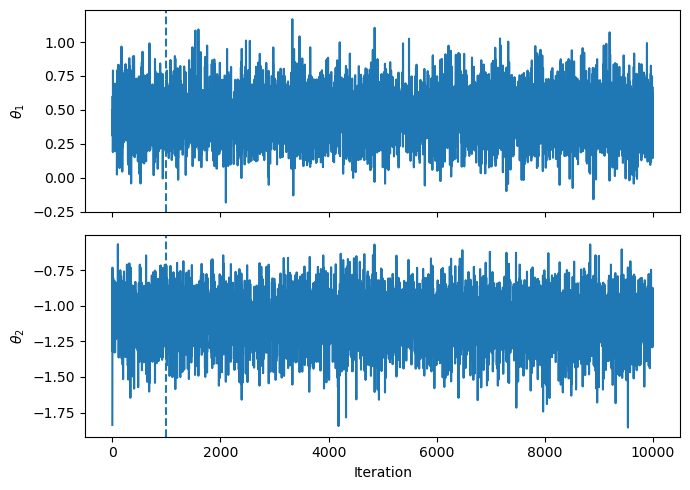

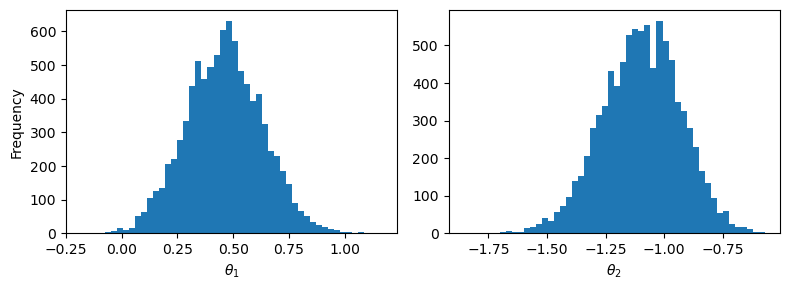

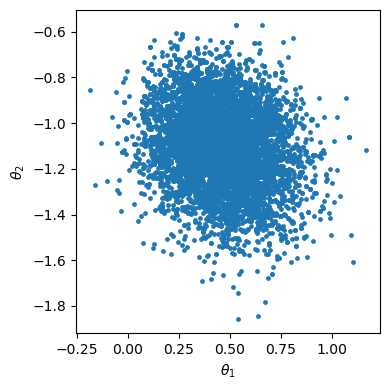

In [2]:
import numpy as np
import matplotlib.pyplot as plt


burn = 1000


fig, axs = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

axs[0].plot(chain[:, 0])
axs[0].axvline(burn, linestyle="--")
axs[0].set_ylabel(r"$\theta_1$")

axs[1].plot(chain[:, 1])
axs[1].axvline(burn, linestyle="--")
axs[1].set_ylabel(r"$\theta_2$")
axs[1].set_xlabel("Iteration")

plt.tight_layout()
plt.savefig("trace_theta.pdf", bbox_inches="tight")
plt.show()


fig, axs = plt.subplots(1, 2, figsize=(8, 3))

axs[0].hist(samples[:, 0], bins=50)
axs[0].set_xlabel(r"$\theta_1$")
axs[0].set_ylabel("Frequency")

axs[1].hist(samples[:, 1], bins=50)
axs[1].set_xlabel(r"$\theta_2$")

plt.tight_layout()
plt.savefig("hist_theta.pdf", bbox_inches="tight")
plt.show()


plt.figure(figsize=(4, 4))
plt.scatter(samples[:, 0], samples[:, 1], s=6)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.tight_layout()
plt.savefig("joint_theta.pdf", bbox_inches="tight")
plt.show()


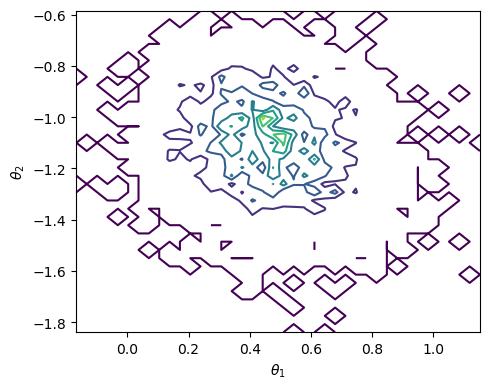

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# samples shape = (N, 2)
theta1 = samples[:, 0]
theta2 = samples[:, 1]

# 2D histogram (density estimate)
H, xedges, yedges = np.histogram2d(theta1, theta2, bins=40, density=True)

# Grid for contour
X, Y = np.meshgrid(
    0.5 * (xedges[:-1] + xedges[1:]),
    0.5 * (yedges[:-1] + yedges[1:])
)

# Plot posterior density contours
plt.figure(figsize=(5, 4))
plt.contour(X, Y, H.T)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.tight_layout()
plt.savefig("posterior_density.pdf", bbox_inches="tight")
plt.show()


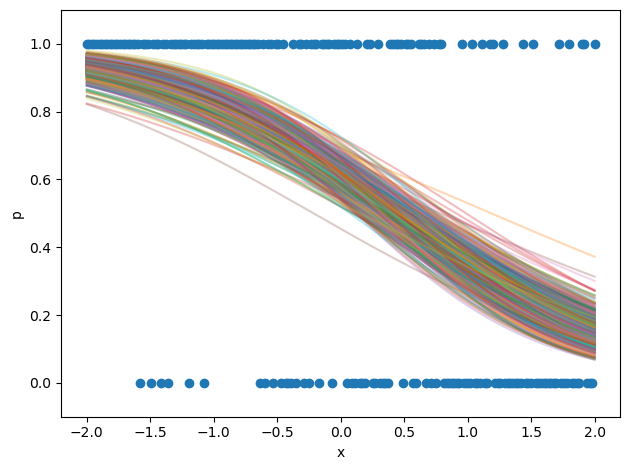

In [4]:
import numpy as np
import matplotlib.pyplot as plt


plt.scatter(x, y)
plt.xlabel("x")
plt.ylabel("p")
plt.ylim(-0.1, 1.1)


x_grid = np.linspace(np.min(x), np.max(x), 200)

for theta in samples[::20]:   # samples from MALA
    p_curve = 1 / (1 + np.exp(-(theta[0] + theta[1] * x_grid)))
    plt.plot(x_grid, p_curve, alpha=0.3)

plt.tight_layout()
plt.savefig("posterior_predictive_mala_well.pdf", bbox_inches="tight")
plt.show()


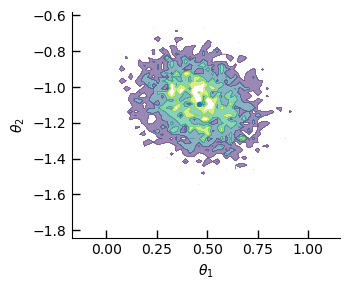

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# --- Extract samples ---
t1 = samples[:, 0]
t2 = samples[:, 1]

# --- 2D density estimate via histogram (no extra libraries) ---
bins = 60
H, xedges, yedges = np.histogram2d(t1, t2, bins=bins, density=True)

# Bin centers for plotting
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xc, yc, indexing="xy")

# Transpose H to match X,Y orientation
Z = H.T

# --- Publication-style contour levels (quantile-based) ---
Zpos = Z[Z > 0]
levels = np.quantile(Zpos, [0.50, 0.70, 0.85, 0.93, 0.97])

# --- Plot ---
plt.figure(figsize=(3.6, 3.0))

# Filled contours + contour lines
plt.contourf(X, Y, Z, levels=levels, alpha=0.55)
plt.contour(X, Y, Z, levels=levels, linewidths=0.2)

# Optional: show posterior mean as a marker (from samples only)
plt.plot(t1.mean(), t2.mean(), marker="o", markersize=3)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

# Clean axes (journal-like)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="in", length=6, width=1)

plt.tight_layout()
plt.savefig("posterior_contours.png", bbox_inches="tight")
plt.show()


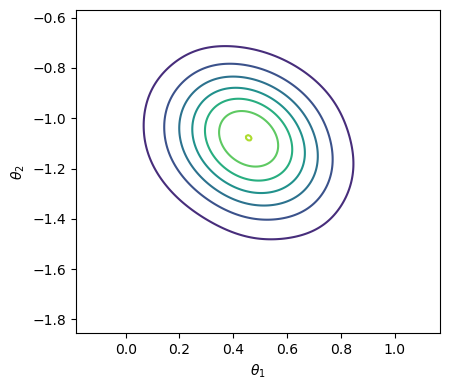

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

t1, t2 = samples[:, 0], samples[:, 1]
kde = gaussian_kde(np.vstack([t1, t2]), bw_method=0.6)  # larger = smoother

x = np.linspace(t1.min(), t1.max(), 200)
y = np.linspace(t2.min(), t2.max(), 200)
X, Y = np.meshgrid(x, y)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

plt.figure(figsize=(4.6, 4.0))
plt.contour(X, Y, Z, levels=7)
plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")
plt.tight_layout()
plt.savefig("posterior_kde_contours.pdf", bbox_inches="tight")
plt.show()



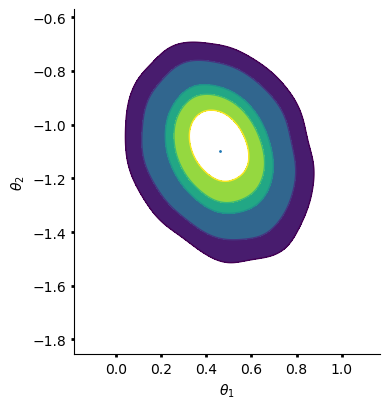

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

t1, t2 = samples[:, 0], samples[:, 1]
kde = gaussian_kde(np.vstack([t1, t2]), bw_method=0.4)

# grid
nx = 250
x = np.linspace(t1.min(), t1.max(), nx)
y = np.linspace(t2.min(), t2.max(), nx)
X, Y = np.meshgrid(x, y)

Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(nx, nx)

# smooth, well-spaced contour levels (density quantiles)
Zpos = Z[Z > 0]
levels = np.quantile(Zpos, [0.70, 0.80, 0.9, 0.93, 0.97])

plt.figure(figsize=(4.0, 4.2))

plt.contourf(X, Y, Z, levels=levels)
plt.contour(X, Y, Z, levels=levels, linewidths=1.0)

# mark posterior mean (from samples only)
plt.plot(t1.mean(), t2.mean(), marker="o", markersize=1)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=2, width=2)

plt.tight_layout()
plt.savefig("posterior_kde_contours.png")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

t1, t2 = samples[:, 0], samples[:, 1]
kde = gaussian_kde(np.vstack([t1, t2]), bw_method=0.4)

# grid
x = np.linspace(t1.min(), t1.max(), 300)
y = np.linspace(t2.min(), t2.max(), 300)
X, Y = np.meshgrid(x, y)

Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# contour levels based on density
Zpos = Z[Z > 0]
levels = np.quantile(Zpos, [0.1, 0.11, 0.111, 0.112, 0.13, 0.133, 0.14, 0.144, 1.0, 1.11, 1.12, 1.13 ,0.6, 0.75, 0.85, 0.92, 0.97])

plt.figure(figsize=(4.8, 4.2))

plt.contour(X, Y, Z, levels=levels, linewidths=1.2)

# posterior mean
plt.plot(t1.mean(), t2.mean(), "o", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=4, width=1)

plt.tight_layout()
plt.savefig("posterior_kde_contours_lines.png", bbox_inches="tight")
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

t1, t2 = samples[:, 0], samples[:, 1]
kde = gaussian_kde(np.vstack([t1, t2]), bw_method=0.4)

# grid
nx = 800
x = np.linspace(t1.min(), t1.max(), nx)
y = np.linspace(t2.min(), t2.max(), nx)
X, Y = np.meshgrid(x, y)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# many contour levels (must be in [0,1])
Zpos = Z[Z > 0]
qs = np.linspace(0.5, 0.9, 20)          # 25 lines (increase if you want)
levels = np.quantile(Zpos, qs)

plt.figure(figsize=(4.8, 4.2))
plt.contour(X, Y, Z, levels=levels, linewidths=1.0)

plt.plot(t1.mean(), t2.mean(), "o", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(direction="out", length=4, width=1)

plt.tight_layout()
plt.savefig("posterior_kde_contours_lines.png", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(4.8, 4.2))

plt.contourf(X, Y, Z, levels=50, cmap="viridis")
plt.contour(X, Y, Z, levels=30, colors="k", linewidths=0.6)

plt.plot(t1.mean(), t2.mean(), "ro", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_filled.pdf", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(4.8, 4.2))

# filled contours (inside only)
levels_f = np.linspace(Z.min(), Z.max(), 40)
plt.contourf(X, Y, Z, levels=levels_f, cmap="viridis", extend="neither")

# white contour lines
levels_l = np.linspace(Z.min(), Z.max(), 25)
plt.contour(X, Y, Z, levels=levels_l, colors="white", linewidths=0.8)

# posterior mean
plt.plot(t1.mean(), t2.mean(), "ro", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_filled_white_lines.pdf", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(4.8, 4.2))

# threshold to keep background white
z_min = Z.max() * 0.05
levels_f = np.linspace(z_min, Z.max(), 40)

# filled contours (only where density is not too small)
plt.contourf(X, Y, Z, levels=levels_f, cmap="viridis")

# black contour lines
levels_l = np.linspace(z_min, Z.max(), 25)
plt.contour(X, Y, Z, levels=levels_l, colors="black", linewidths=0.8)

# posterior mean
plt.plot(t1.mean(), t2.mean(), "ro", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_clean_white_bg.png", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(4.8, 4.2))

# threshold to keep background white
z_min = Z.max() * 0.05

# 6 blue density levels
levels_f = np.linspace(z_min, Z.max(), 6)

# filled contours (blue shades only)
plt.contourf(X, Y, Z, levels=levels_f, cmap="Blues")

# black contour lines (more levels for smooth shape)
levels_l = np.linspace(z_min, Z.max(), 20)
plt.contour(X, Y, Z, levels=levels_l, colors="black", linewidths=0.8)

# posterior mean
plt.plot(t1.mean(), t2.mean(), "ro", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_blue6.png", bbox_inches="tight")
plt.show()


In [ ]:
plt.figure(figsize=(4.8, 4.2))

# keep background white (cut very low density)
z_min = Z.max() * 0.025

# many smooth levels
levels = np.linspace(z_min, Z.max(), 30)

# filled contours (blue shades)
plt.contourf(X, Y, Z, levels=levels, cmap="Blues")

# contour lines with SAME colormap
plt.contour(X, Y, Z, levels=levels, cmap="Blues", linewidths=1.0)

# posterior mean
plt.plot(t1.mean(), t2.mean(), "ro", markersize=3)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_blue_smooth.png", bbox_inches="tight")
plt.show()



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib import cm, colors

t1, t2 = samples[:, 0], samples[:, 1]
kde = gaussian_kde(np.vstack([t1, t2]), bw_method=0.3)

nx = 300
x = np.linspace(t1.min(), t1.max(), nx)
y = np.linspace(t2.min(), t2.max(), nx)
X, Y = np.meshgrid(x, y)
Z = kde(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

# keep background white by cutting very low density
z_min = Z.max() * 0.05
levels = np.linspace(z_min, Z.max(), 25)

# use only the darker part of "Blues" so edges stay cyan (not white)
base = cm.get_cmap("Blues")
cmap = colors.ListedColormap(base(np.linspace(0.25, 1.0, 256)))

plt.figure(figsize=(4.8, 4.2))

plt.contourf(X, Y, Z, levels=levels, cmap=cmap)
plt.contour(X, Y, Z, levels=levels, cmap=cmap, linewidths=1.0)

plt.plot(t1.mean(), t2.mean(), "ro", markersize=4)

plt.xlabel(r"$\theta_1$")
plt.ylabel(r"$\theta_2$")

ax = plt.gca()
ax.set_facecolor("white")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("posterior_kde_contours_blue_cyan_edges.png", bbox_inches="tight")
plt.show()
